The image was successfully loaded
Image in BGR with matplotlib


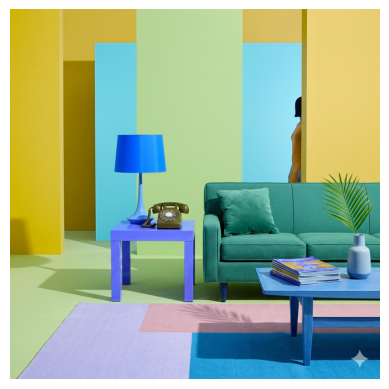

Image in RGB with matplotlib


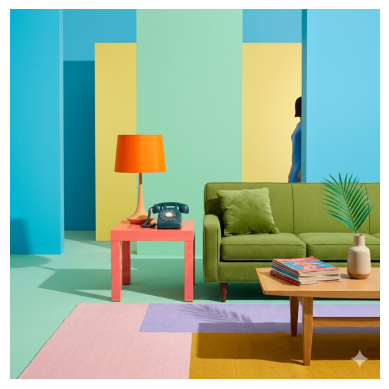

Image in Grays with matplotlib
(1024, 1024)


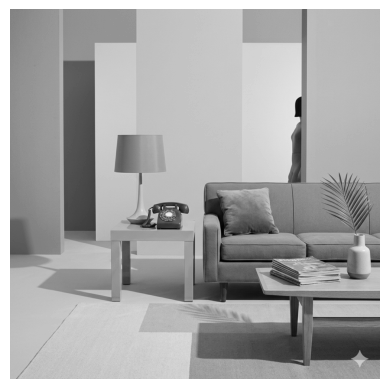

BGR pixel:  [215 189  51]
RGB pixel:  [ 51 189 215]
Gray pixel:  151


In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_path = "images/livingroom.png"
img = cv2.imread(img_path)

if img is None:
    print("The image coudn't be found")
else:
    print("The image was successfully loaded")

rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
grays_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Image in BGR with matplotlib")
plt.imshow(img, vmin=0, vmax=255)
plt.axis('off')
plt.show()

print("Image in RGB with matplotlib")
plt.imshow(rgb_img, vmin=0, vmax=255)
plt.axis('off')
plt.show()

print("Image in Grays with matplotlib")
print(grays_image.shape)
plt.imshow(grays_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

x = y = 100
bgr_pixel = img[x, y]
rgb_pixel = rgb_img[x, y]
gray_pixel = grays_image[x, y]
print("BGR pixel: ", bgr_pixel)
print("RGB pixel: ", rgb_pixel)
print("Gray pixel: ", gray_pixel)

Blue component


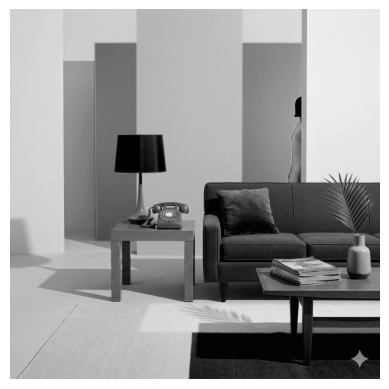

Green component


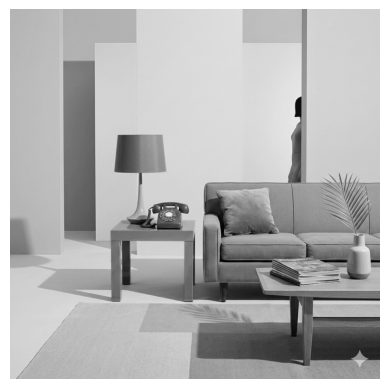

Red component


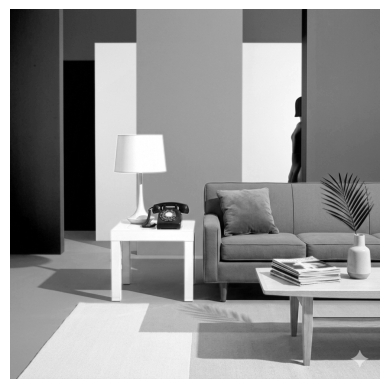

In [7]:
blue, green, red = cv2.split(img)

print("Blue component")
plt.imshow(blue, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

print("Green component")
plt.imshow(green, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

print("Red component")
plt.imshow(red, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

Hue component


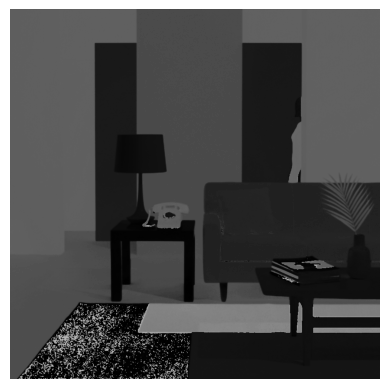

Saturation component


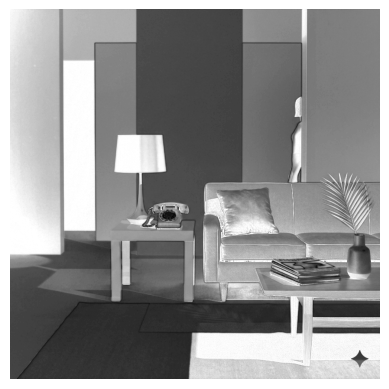

Value component


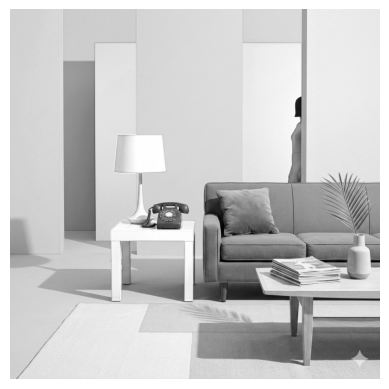

In [10]:
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
hue, saturation, value = cv2.split(hsv_img)

print("Hue component")
plt.imshow(hue, cmap="gray", vmin=0, vmax=255)
plt.axis('off')
plt.show()

print("Saturation component")
plt.imshow(saturation, cmap="gray", vmin=0, vmax=255)
plt.axis('off')
plt.show()

print("Value component")
plt.imshow(value, cmap="gray", vmin=0, vmax=255)
plt.axis('off')
plt.show()

Mask shape:  (1024, 1024)
Result shape:  (1024, 1024, 3)
255
0
Mask image


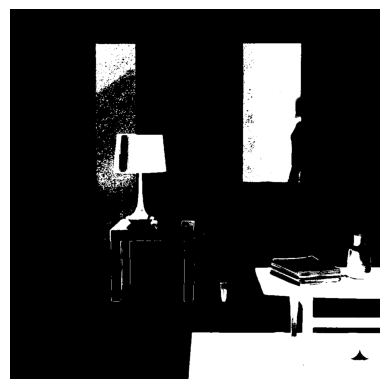

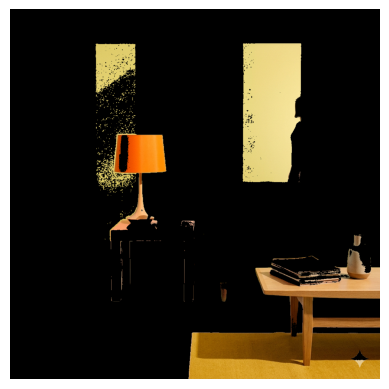

Saved:  True


In [22]:
# Trying to detect orange in the image
lower_orange = np.array([10, 80, 50], dtype=np.uint8)
upper_orange = np.array([25, 255, 255], dtype=np.uint8)

mask = cv2.inRange(hsv_img, lower_orange, upper_orange) #this gives a mask 0s and 255s so bitwise and is possible
result = cv2.bitwise_and(rgb_img, rgb_img, mask=mask)

print("Mask shape: ", mask.shape)
print("Result shape: ", result.shape)
print(np.max(result))
print(np.min(result))

print("Mask image")
plt.imshow(mask, cmap="gray", vmin=0, vmax=255)
plt.axis('off')
plt.show()

plt.imshow(result, vmin=0, vmax=255)
plt.axis('off')
plt.show()

bgr_resutl = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
success = cv2.imwrite("outputs/filtered_orange_objects_in_livingroom.jpg", bgr_resutl)
print("Saved: ", success)




image with orange objects in bounded box


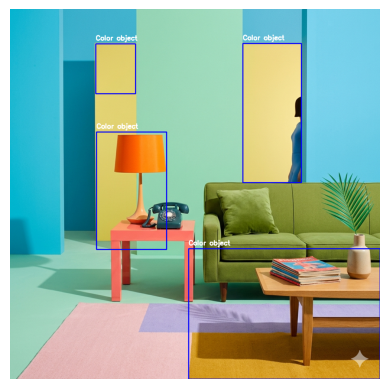

In [20]:
# bounding boxes in colored objects
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = rgb_img.copy()

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 500:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 0, 255), 2)
        cv2.putText(output, "Color object", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)


print("image with orange objects in bounded box")
plt.imshow(output, vmin=0, vmax=255)
plt.axis('off')
plt.show()